# Problem 2: Water Waves
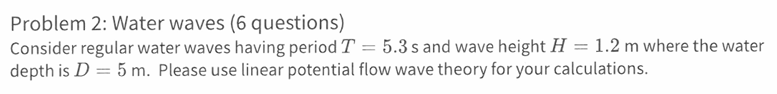

In [105]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation

In [106]:
H_0 = 1.2                   # Deep water wave height [m]
T = 5.3                     # Wave period [s]
g = 9.81                    # Gravitational acceleration [m/s^2]
D = 5                       # Water depth [m] 

### Question 2.1
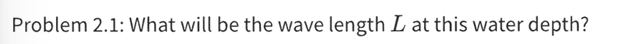

In [126]:
omega = 2 * np.pi / T        # (1/s) Wave angular frequency
k0 = omega**2 / g            # Initial guess for wavenumber

# Solve dispersion relation
func = lambda k0: omega**2 - g * k0 * np.tanh(k0 * D)
k = fsolve(func, k0)
k = k[0]

L = 2 * np.pi / k      # Wavelength
print(f"Wavelength L: {L:.0f} m")
print(f"Wavenumber k: {k:.4f} 1/m")

Wavelength L: 33 m
Wavenumber k: 0.1923 1/m


### Question 2.2
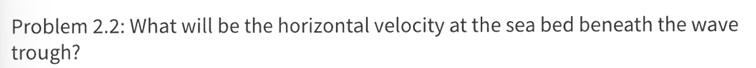


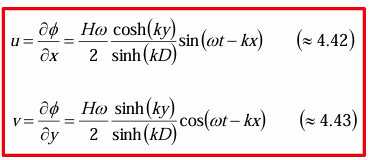
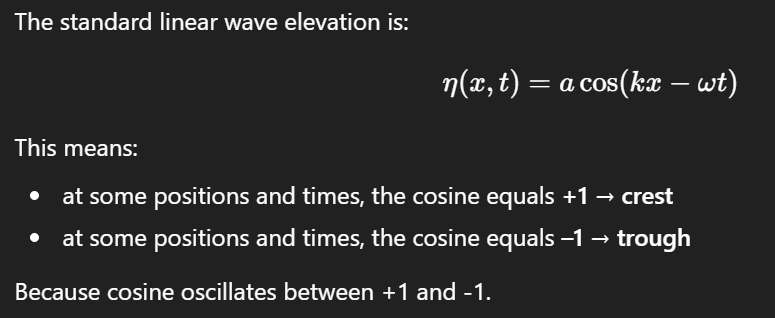

In [108]:
y_bed = 0            # y-coordinate at the sea bed

# Velocity at the sea bed beaneth the wave trough (y = -D)  <--- -1 in the equation means the trough
u_at_y = lambda y: H_0/2 * omega * np.cosh(k*y)/np.sinh(k*D) * -1  # Velocity at depth y


# Print results
print(f"Maximum horizonral velocity at the bed: {u_at_y(y_bed):.2f} m/s")

Maximum horizonral velocity at the bed: -0.64 m/s


### Question 2.3
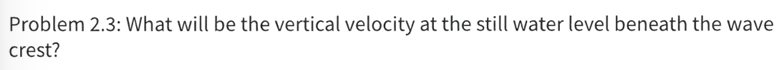

In [109]:
# Velocity at the sea bed beaneth the wave crest (y = -D)
v_at_y = lambda y: H_0/2 * omega * np.sinh(k*y)/np.sinh(k*D) * 1  # Velocity at depth y


# Print results
print(f"Maximum horizonral velocity at the bed: {v_at_y(y_bed):.2f} m/s")

Maximum horizonral velocity at the bed: 0.00 m/s


### Question 2.4
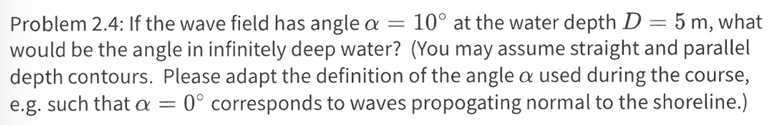

In [110]:
alpha_0 = 10 * np.pi/180    # Wave angle [rad] -> where alpha 0 corresponds to waves propagating normal to the shoreline
L_0 = g * T**2 / (2 * np.pi)                    # deep water wave length [m]
k_0 = 2 * np.pi / L_0                           # deep water wave number [m^-1]
c_0 = np.sqrt(g / k_0)                          # deep water wave celerity [m/s]

def cons_energy_refraction (H, H_0, k, D, alpha, alpha_0): #energy flux conservation with refraction
    G = 2*k*D / np.sinh(2*k*D)
    K_s = np.sqrt(1.0 /(np.tanh(k*D) * (1.0+G)))
    K_r = np.sqrt(np.cos(alpha_0)/np.cos(alpha))
    return H - H_0*K_r*K_s                                  # P6,7,8 eq. 6 p. 34

def dispersion(k, D, T):                                                         #dispersion relation
    omega = 2*np.pi/T
    return omega**2 - g * k * np.tanh(k*D)
      
def Snell_law(alpha, alpha_0, k, k_0):                         #Snell's law --> k_0 * sen (alpha_0) = k * sen(alpha)
    return k * np.sin(alpha_0) - k_0 * np.sin(alpha)


def refraction(D, H_0, k_0, alpha_0, T):
    def system(x):
        H, k, alpha = x
        return np.array([cons_energy_refraction(H, H_0, k, D, alpha, alpha_0),dispersion(k, D, T), Snell_law(alpha, alpha_0, k, k_0)], dtype=float)
    
    H, k, alpha = fsolve(system, x0=[H_0, k_0, alpha_0])
    return H, k, alpha

H_deep, k_deep, alpha = refraction(D, H_0, k_0, alpha_0, T) # in radians
alpha = alpha * 180 / np.pi # in degrees
print(f"Wave angle at depth D: {alpha:.1f} degrees")

Wave angle at depth D: 13.5 degrees


### Question 2.5
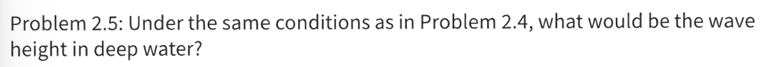

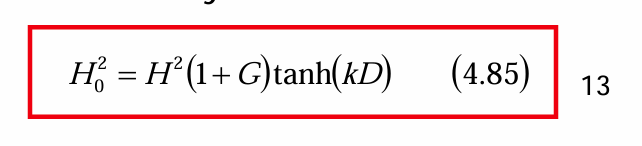

In [114]:
def get_deep_water (H_0, k, D, alpha, alpha_0): #energy flux conservation with refraction
    G = 2*k*D / np.sinh(2*k*D)
    K_s = np.sqrt(1.0 /(np.tanh(k*D) * (1.0+G)))
    K_r = np.sqrt(np.cos(alpha_0)/np.cos(alpha))
    return H_0*K_r*K_s    

H_d = get_deep_water(H_deep, k_deep, D, alpha, alpha_0)

print(f"Wave height at depth D: {H_d:.2f} m")

Wave height at depth D: 1.31 m


### Question 2.6
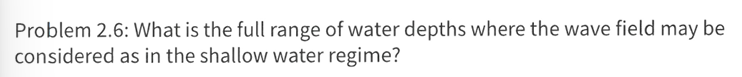](attachment:image-2.png)

In [133]:
# Angular frequency
omega = 2*np.pi / T

# Shallow Water k*D < np.pi/10:
kD = np.pi / 10.0

# Dispersion relation for shallow water
# Dispersion relation: omega^2 = g*k*tanh(k*D)   --> k = omega^2 / (g*tanh(k*D))
k_limit = omega**2 / (g * np.tanh(kD))            # Wavenumber for shallow water

# Rearranged for D = (pi/10)/k for the shallow water condition
D_limit = kD / k_limit                            # Maximum water depth for shallow water


print("D_limit for shallow water = {:.2f} m".format(D_limit))

D_limit for shallow water = 0.67 m
